In [1]:
import pandas as pd
import numpy as np
from numpy import matmul
from scipy import stats
from sklearn import metrics
from numpy.linalg import inv
import random
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
from itertools import chain
import seaborn as sns


In [2]:
def Filter(string, substr):
    return [str for str in string if
             any(sub in str for sub in substr)]

def vectorized_gaussian_logpdf(X, means, covariances):
    # """
    # Compute log N(x_i; mu_i, sigma_i) for each x_i, mu_i, sigma_i
    # Args:
    #     X : shape (d)
    #         Data points
    #     means : shape (self.N, d)
    #         Mean vectors
    #     covariances : shape (self.N, d)
    #         Diagonal covariance matrices
    # Returns:
    #     logpdfs : shape (n,)
    #         Log probabilities
    # """
        d = X.shape[0]
        constant = d * np.log(2 * np.pi)
        log_determinants = np.log(np.prod(covariances, axis=1))
        deviations = X - means
        inverses = 1 / covariances
        return -0.5 * (constant + log_determinants + np.sum(deviations * inverses * deviations, axis=1))

def vectorized_norm_loglikelihood(X, means, covariances, delta):
    #  '''
    #  Compute log Norm(X_i, mu_i, sigma_i) for each x_i, mu_i, sigma_i
    #  Args:
    #      X: shape (n,)
    #      means: shape (n,d)
    #      covariances (d,)
    #  Returns: logsf: shape (d,)
    #  '''
    loglikelihood = [delta*np.log(stats.norm.pdf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) + (1-delta)*np.log(stats.norm.sf(x = X, loc=means[:, i], scale=np.sqrt(covariances[i]))) for i in range(means.shape[1])]
    loglikelihood = np.array(loglikelihood).sum(axis=1)
    return loglikelihood

In [3]:
IND_TRAIN = [[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
             [0,1,2,3,4,5,6,7,8,9,10,11,16,17,18,19],
             [0,1,2,3,4,5,6,7,12,13,14,15,16,17,18,19],
             [0,1,2,3,8,9,10,11,12,13,14,15,16,17,18,19],
             [4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]]
IND_TEST = [[16,17,18,19],
            [12,13,14,15],
            [8,9,10,11],
            [4,5,6,7],
            [0,1,2,3]]

In [5]:
Z_Y = []
Z_X = []
BETA_Y = []
TAU_Y = []
BETA_X = []
TAU_X = []
data_train = []
ind_train = IND_TRAIN[0]
ind_test = IND_TEST[0]
for i in ind_train:
    dat = pd.read_csv(f'Simulation_3_cluster_subset_{i+1}.csv', index_col=0)
    z_y = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_Z_Y_records.csv', index_col=0)
    z_x = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_Z_X_records.csv', index_col=0)
    beta_y = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_BETA_Y_records.csv', index_col=0)
    tau_y = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_TAU_Y_records.csv', index_col=0)
    beta_x = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_BETA_X_records.csv', index_col=0)
    tau_x = pd.read_csv(f'{i+1}/Simulation 3_{i+1}_TAU_X_records.csv', index_col=0)
    Z_Y.append(z_y)
    Z_X.append(z_x)
    BETA_Y.append(beta_y)
    TAU_Y.append(tau_y)
    BETA_X.append(beta_x)
    TAU_X.append(tau_x)
    data_train.append(dat)


In [6]:
data_test=[]
for i in ind_test:
    dat = pd.read_csv(f'Simulation_3_cluster_subset_{i+1}.csv', index_col=0)
    data_test.append(dat)

In [7]:
Training = pd.concat(data_train, ignore_index=True)
Training['y'] = np.log(Training['y'])
true_train_z_y = Training['Z']
true_train_y = Training['y']
true_train_sf = Training['true_sf']
Testing = pd.concat(data_test, ignore_index=True)
Testing['y'] = np.log(Testing['y'])
true_test_z_y = Testing['Z']
true_test_y = Testing['y']
true_test_sf = Testing['true_sf']
delta_test = Testing['C']
Testing1 = Testing.drop(columns=['Z', 'C', 'y','true_sf'])
X_name = Testing1.columns

In [8]:
n_subsets_cluster_y = [[Z_Y[j].iloc[:,i].nunique() for j in range(16)] for i in range(50)]
random.seed(10)
reference_subset = random.choices(range(16),k=50)

In [9]:
Agg_z_y = [Z_Y[i].copy() for i in range(16)]

for t in range(50):
    i = reference_subset[t]
    target_z_y = Z_Y[i].iloc[:,t]
    n_N_y = target_z_y.value_counts(sort=False).sort_index().values
    beta_y = BETA_Y[i]
    name_beta_y = Filter(beta_y.columns, [f'in_{t+1}_iteration'])
    target_beta_y = beta_y[name_beta_y].values
    tau_y = TAU_Y[i]
    name_tau_y = Filter(tau_y.columns, [f'in_{t+1}_iteration'])
    target_tau_y = tau_y[name_tau_y].values
    for k in range(16):
        n_n = n_subsets_cluster_y[t][k]
        # print(f'the {k+1}th subset in the {t+1}th iteration')
        if k != i:
            DAT = data_train[k]
            for ii in range(data_train[k].shape[0]):
                yi, deltai = data_train[k].loc[ii, ['y', 'C']]
                yi = np.log(yi)
                xi = data_train[k].loc[ii, X_name].values
                mean_y = matmul(xi, target_beta_y)
                likelihood_y = deltai*stats.norm.pdf(yi, loc=mean_y, scale=np.sqrt(target_tau_y)) + (1-deltai)*stats.norm.sf(yi, loc=mean_y, scale=np.sqrt(target_tau_y))
                likelihood_y = np.nan_to_num(likelihood_y, nan=-np.inf)
                true_z_y = np.argmax(n_N_y*likelihood_y)
                Agg_z_y[k].loc[ii, f'z_y_{t+1}_iteration'] = true_z_y


In [10]:
train_RI = []
train_MI = []
train_ARI = []
train_AMI = []
train_HOMO = []
train_COM = []
train_VM = []
train_FM = []
AGG_Z_Y = pd.concat(Agg_z_y, ignore_index=True)
AGG_Z_Y.to_csv('''train_z_y_unit_agg.csv''')
# print(AGG_Z_Y)
for j in range(AGG_Z_Y.shape[1]):
    ri = metrics.rand_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    mi = metrics.mutual_info_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    ari = metrics.adjusted_rand_score(true_train_z_y,AGG_Z_Y.iloc[:,j])
    ami = metrics.adjusted_mutual_info_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    hcv = metrics.homogeneity_completeness_v_measure(true_train_z_y, AGG_Z_Y.iloc[:,j])
    fm = metrics.fowlkes_mallows_score(true_train_z_y, AGG_Z_Y.iloc[:,j])
    train_RI.append(ri)
    train_MI.append(mi)
    train_ARI.append(ari)
    train_AMI.append(ami)
    train_HOMO.append(hcv[0])
    train_COM.append(hcv[1])
    train_VM.append(hcv[2])
    train_FM.append(fm)

    
    



In [18]:
res = pd.DataFrame({'Train-RI': [np.array(train_RI).mean(), np.array(train_RI).std()],'Train-MI': [np.array(train_MI).mean(), np.array(train_MI).std()],'Train-ARI': [np.array(train_ARI).mean(), np.array(train_ARI).std()], 'Train-AMI': [np.array(train_AMI).mean(), np.array(train_AMI).std()],'Train-HOMO': [np.array(train_HOMO).mean(), np.array(train_HOMO).std()], 'Train-COM': [np.array(train_COM).mean(), np.array(train_COM).std()], 'Train-VM': [np.array(train_VM).mean(), np.array(train_VM).std()], 'Train-FM': [np.array(train_FM).mean(), np.array(train_FM).std()]}, index=['mean', 'std'])
print(res)

      Train-RI  Train-MI  Train-ARI  Train-AMI  Train-HOMO  Train-COM  \
mean  0.993314  1.071579   0.985094   0.975212    0.975393   0.975063   
std   0.018774  0.037110   0.041268   0.031505    0.033779   0.029120   

      Train-VM  Train-FM  
mean  0.975220  0.990166  
std   0.031493  0.026783  


In [31]:
##### Subset clustering
train_ARI = []
train_AMI = []
train_VM = []
train_FM = []
for i in range(16):
    true_train_z_y = data_train[i]['Z']
    ARI = []
    AMI = []
    VM = []
    FM = []
    for j in range(50):
        ari = metrics.adjusted_rand_score(true_train_z_y,Agg_z_y[i].iloc[:,j])
        ami = metrics.adjusted_mutual_info_score(true_train_z_y, Agg_z_y[i].iloc[:,j])
        hcv = metrics.homogeneity_completeness_v_measure(true_train_z_y, Agg_z_y[i].iloc[:,j])
        fm = metrics.fowlkes_mallows_score(true_train_z_y, Agg_z_y[i].iloc[:,j])
        ARI.append(ari)
        AMI.append(ami)
        VM.append(hcv[2])
        FM.append(fm)
    ARI = np.array(ARI).mean()
    AMI = np.array(AMI).mean()
    VM = np.array(VM).mean()
    FM = np.array(FM).mean()
    train_ARI.append(ARI)
    train_AMI.append(AMI)
    train_VM.append(VM)
    train_FM.append(FM)
subsetcluster = pd.DataFrame({'ARI': train_ARI, 'AMI': train_AMI, 'VM': train_VM, 'FM': train_FM})
print(subsetcluster.T)

           0         1         2         3         4         5         6   \
ARI  0.983769  0.988808  0.983485  0.983422  0.983755  0.982161  0.986825   
AMI  0.976911  0.985616  0.976121  0.976332  0.977090  0.973103  0.982075   
VM   0.976998  0.985671  0.976214  0.976421  0.977181  0.973205  0.982145   
FM   0.989300  0.992623  0.989100  0.989071  0.989300  0.988179  0.991307   

           7         8         9         10        11        12        13  \
ARI  0.983252  0.983635  0.984201  0.988595  0.986842  0.984169  0.992289   
AMI  0.976219  0.976125  0.977400  0.985580  0.982153  0.977680  0.985655   
VM   0.976309  0.976215  0.977486  0.985634  0.982219  0.977762  0.985710   
FM   0.988985  0.989178  0.989565  0.992500  0.991322  0.989570  0.994849   

           14        15  
ARI  0.982764  0.984800  
AMI  0.974686  0.978583  
VM   0.974781  0.978665  
FM   0.988611  0.989972  


In [11]:
column_name = Z_Y[0].columns
Agg_z_y_test = [pd.DataFrame(np.ones((data_test[i].shape[0], 50)), columns=column_name) for i in range(4)]
for t in range(50):
    i = reference_subset[t]
    n_n = n_subsets_cluster_y[t][i]
    target_z_y = Z_Y[i].iloc[:,t]
    n_N_y = target_z_y.value_counts(sort=False).sort_index().values
    beta_y = BETA_Y[i]
    name_beta_y = Filter(beta_y.columns, [f'in_{t+1}_iteration'])
    target_beta_y = beta_y[name_beta_y].values
    target_beta_y = target_beta_y[:,:n_n]
    tau_y = TAU_Y[i]
    name_tau_y = Filter(tau_y.columns, [f'in_{t+1}_iteration'])
    target_tau_y = tau_y[name_tau_y].values
    target_tau_y = target_tau_y[:,:n_n]
    for k in range(4):
        for ii in range(data_test[k].shape[0]):
            yi, deltai = data_test[k].loc[ii, ['y', 'C']]
            yi = np.log(yi)
            xi = data_test[k].loc[ii, X_name].values
            mean_y = matmul(xi, target_beta_y)
            likelihood_y = deltai*stats.norm.pdf(yi, loc=mean_y, scale=np.sqrt(target_tau_y)) + (1-deltai)*stats.norm.sf(yi, loc=mean_y, scale=np.sqrt(target_tau_y))
            likelihood_y = np.nan_to_num(likelihood_y, nan=-np.inf)
            true_z_y = np.argmax(n_N_y*likelihood_y)
            Agg_z_y_test[k].loc[ii, f'z_y_{t+1}_iteration'] = true_z_y


In [12]:
test_RI = []
test_MI = []
test_ARI = []
test_AMI = []
test_HOMO = []
test_COM = []
test_VM = []
test_FM = []
AGG_Z_Y_test = pd.concat(Agg_z_y_test, ignore_index=True)
AGG_Z_Y_test.to_csv('test_z_y_unit_agg.csv')
for j in range(50):
    ri = metrics.rand_score(true_test_z_y, AGG_Z_Y_test.iloc[:,j])
    mi = metrics.mutual_info_score(true_test_z_y, AGG_Z_Y_test.iloc[:,j])
    ari = metrics.adjusted_rand_score(true_test_z_y,AGG_Z_Y_test.iloc[:,j])
    ami = metrics.adjusted_mutual_info_score(true_test_z_y, AGG_Z_Y_test.iloc[:,j])
    hcv = metrics.homogeneity_completeness_v_measure(true_test_z_y, AGG_Z_Y_test.iloc[:,j])
    fm = metrics.fowlkes_mallows_score(true_test_z_y, AGG_Z_Y_test.iloc[:,j])
    test_RI.append(ri)
    test_MI.append(mi)
    test_ARI.append(ari)
    test_AMI.append(ami)
    test_HOMO.append(hcv[0])
    test_COM.append(hcv[1])
    test_VM.append(hcv[2])
    test_FM.append(fm)

In [22]:
res = pd.DataFrame({'Test-RI': [np.array(test_RI).mean(), np.array(test_RI).std()],'Test-MI': [np.array(test_MI).mean(), np.array(test_MI).std()],'Test-ARI': [np.array(test_ARI).mean(), np.array(test_ARI).std()], 'Test-AMI': [np.array(test_AMI).mean(), np.array(test_AMI).std()],'Test-HOMO': [np.array(test_HOMO).mean(), np.array(test_HOMO).std()], 'Test-COM': [np.array(test_COM).mean(), np.array(test_COM).std()], 'Test-VM': [np.array(test_VM).mean(), np.array(test_VM).std()], 'Test-FM': [np.array(test_FM).mean(), np.array(test_FM).std()]}, index=['mean', 'std'])
print(res)

       Test-RI   Test-MI  Test-ARI  Test-AMI  Test-HOMO  Test-COM   Test-VM  \
mean  0.992938  1.072033  0.984291  0.976209   0.975807  0.976676  0.976231   
std   0.020963  0.041009  0.045974  0.034647   0.037328  0.031768  0.034615   

       Test-FM  
mean  0.989664  
std   0.029750  


In [32]:
##### Subset clustering
test_ARI = []
test_AMI = []
test_VM = []
test_FM = []
for i in range(4):
    true_test_z_y = data_test[i]['Z']
    ARI = []
    AMI = []
    VM = []
    FM = []
    for j in range(50):
        ari = metrics.adjusted_rand_score(true_test_z_y,Agg_z_y_test[i].iloc[:,j])
        ami = metrics.adjusted_mutual_info_score(true_test_z_y, Agg_z_y_test[i].iloc[:,j])
        hcv = metrics.homogeneity_completeness_v_measure(true_test_z_y, Agg_z_y_test[i].iloc[:,j])
        fm = metrics.fowlkes_mallows_score(true_test_z_y, Agg_z_y_test[i].iloc[:,j])
        ARI.append(ari)
        AMI.append(ami)
        VM.append(hcv[2])
        FM.append(fm)
    ARI = np.array(ARI).mean()
    AMI = np.array(AMI).mean()
    VM = np.array(VM).mean()
    FM = np.array(FM).mean()
    test_ARI.append(ARI)
    test_AMI.append(AMI)
    test_VM.append(VM)
    test_FM.append(FM)
subsetcluster = pd.DataFrame({'ARI': test_ARI, 'AMI': test_AMI, 'VM': test_VM, 'FM': test_FM})
print(subsetcluster.T)

            0         1         2         3
ARI  0.982776  0.984595  0.986192  0.987478
AMI  0.974860  0.977744  0.981017  0.983774
VM   0.974953  0.977826  0.981087  0.983835
FM   0.988628  0.989814  0.990891  0.991773


In [23]:
DD = []
NN = []
for t in range(50):
    # print(t)
    i = reference_subset[t]
    agg_z_y_i = np.sort(AGG_Z_Y[f'z_y_{t+1}_iteration'].unique())
    D_i = []
    N_i = []
    for s in agg_z_y_i:
        # print(s)
        D_ii = []
        N_ii = []
        for k in range(16):
            agg_z_y_k = Agg_z_y[k][f'z_y_{t+1}_iteration']
            ind = agg_z_y_k[agg_z_y_k == s].index
            zz = Z_Y[k].loc[ind, f'z_y_{t+1}_iteration'].value_counts()
            D_ii.append(list(zz.index))
            N_ii.append(zz.values)
        N_i.append(N_ii)
        D_i.append(D_ii)
    DD.append(D_i)
    NN.append(N_i)


In [24]:
def N_hl(i,k):
    z_i = Agg_z_y[k].iloc[i,].values
    N_hl = [NN[t][z_i[t]] for t in range(50)]
    return N_hl

def theta_bracket(i,k):
    z_i = Agg_z_y[k].iloc[i,].values
    zzi = [DD[t][z_i[t]] for t in range(50)]
    N = N_hl(i,k)
    bb = []
    tt = []
    for t in range(50):
        bbb = []
        ttt = []
        nnn = []
        nn = sum(chain.from_iterable(N[t]))
        # print(nn)
        for s in range(len(zzi[t])):
            nii = N[t][s]
            if len(nii) == 0:
                nnn.append(0)
                bbbb = np.ones(50)*0
                tttt = np.ones(1)*1
            else:
                ind = np.argmax(nii)
                nnn.append(nii[ind])
                bbbb = nii[ind]*BETA_Y[s][f'beta_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
                tttt = nii[ind]*TAU_Y[s][f'tau_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
            bbb.append(bbbb)
            ttt.append(tttt)
        bbb = np.array(bbb).sum(axis=0)/sum(nnn)
        ttt = np.array(ttt).sum(axis=0)/sum(nnn)
        bb.append(bbb)
        tt.append(ttt)
    return np.array(bb), np.array(tt)

def N_si(i,k):
    '''
    i: the ith data point
    '''
    z_i = Agg_z_y[k].iloc[i,].values
    N = []
    for j in range(z_i.shape[0]):
        n_i_t = sum(AGG_Z_Y[f'z_y_{j+1}_iteration'] == z_i[j])
        N.append(n_i_t)
    return np.array(N)   

def theta_hat(i,k):
    bb, tt = theta_bracket(i,k)
    N = N_si(i,k)
    beta_i_t = sum([N[t]*bb[t] for t in range(50)])/sum(N)
    tau_i_t = sum([N[t]*tt[t] for t in range(50)])/sum(N)
    return beta_i_t, tau_i_t

def Agg_sf_train(i,k,t):
    beta_i_hat, tau_i_hat = theta_hat(i,k)
    beta_i_bracket, tau_i_bracket = theta_bracket(i,k)
    z_i = Agg_z_y[k].iloc[i,].values
    z_i = z_i.astype(int)
    beta_subset = np.array([BETA_Y[reference_subset[t]][f'beta_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    tau_subset = np.array([TAU_Y[reference_subset[t]][f'tau_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    # z_subset = Z_Y[k].iloc[i,].values
    # beta_subset = np.array([BETA_Y[k][f'beta_y_cluster{z_subset[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    # tau_subset = np.array([TAU_Y[k][f'tau_y_cluster{z_subset[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    Nii = N_si(i,k)
    y_i = data_train[k].loc[i,'y']
    true_sf = data_train[k].loc[i, 'true_sf']
    x_i = data_train[k].loc[i, X_name].values
    bbbeta = beta_subset + beta_i_hat - beta_i_bracket
    tttau = tau_subset + tau_i_hat - tau_i_bracket
    y_mean = matmul(bbbeta, x_i)
    # y_mean_hat = matmul(beta_i_hat, x_i)
    # y_mean_bracket = matmul(beta_i_bracket, x_i)
    # y_mean_subset = matmul(beta_subset, x_i)
    sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
    # print(sf.mean(), true_sf)
    # print(y_mean.mean(), ',real y:', np.log(y_i))
    return matmul(sf,Nii)/sum(Nii), true_sf


In [25]:
EST_SF_TRAIN = []
EST_SF_TRAIN_16_SUBSETS = []
column_name = [f'{i+1}th_sf' for i in range(50)]
for k in range(16):
    EST_sf = []
    TRUE_sf = []
    EST_SF_ALL_ITERATIONS = []
    for i in range(data_train[k].shape[0]):
        est_sf, true_sf = Agg_sf_train(i,k, data_train[k].loc[i,'y'])
        EST_SF_ALL_ITERATIONS.append(est_sf)
        est_sf = est_sf.mean()
        # print(est_sf, true_sf)
        EST_sf.append(est_sf)
        TRUE_sf.append(true_sf)
    EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
    EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS, columns=column_name)
    EST_SF_TRAIN_16_SUBSETS.append(EST_SF_ALL_ITERATIONS)
    EST_sf = np.array(EST_sf)
    TRUE_sf = np.array(TRUE_sf)
    est_sf_train = pd.DataFrame({'est_sf': EST_sf, 'true_sf': TRUE_sf, 'c': data_train[k]['C'].values, 'true_z': data_train[k]['Z']})
    EST_SF_TRAIN.append(est_sf_train)

    # plt.scatter(EST_sf, TRUE_sf)
    # plt.plot([0,1], [0,1], color='red', linewidth=3)
    # plt.show()
    
    SSres = (EST_sf - TRUE_sf)**2
    SSres = np.nan_to_num(SSres, nan=0)
    SSres = SSres.sum()
    SStot = ((TRUE_sf - TRUE_sf.mean())**2).sum()
    R_2 = 1-SSres/SStot
    MSE = np.nan_to_num((EST_sf - TRUE_sf)**2, nan=0).mean()
    print(R_2, MSE)

C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))


0.8615726182164409 0.011930998462248722
0.8425648834237629 0.01426336610296879
0.8608125486374117 0.012950453327118003
0.8624975335117877 0.012657093066692712
0.8572978406230977 0.012700118028348733
0.8401003524208904 0.014358970911183369
0.8481630329216077 0.013294649278957654
0.8570639512605672 0.01265659605134559
0.8417741572565279 0.01444691621247425
0.8479262032830124 0.014467290436854236
0.8530861713004986 0.013617424481317588
0.8389535542570384 0.013988359852257031
0.842971976256903 0.013099355967482046
0.8520984654128129 0.012220739871692528
0.8384289543170345 0.013836248644401404
0.8593107355876365 0.012008399444487127


In [48]:
for s in range(16):
    CItrain = []
    for i in range(50):
        train_correct = []
        train_incorrect = []
        train_base = []
        for j in range(3):
            time_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'y'].values
            event_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'C'].values
            pred_train = data_train[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
            c_train_true = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
            pred_train = EST_SF_TRAIN_16_SUBSETS[s].loc[Agg_z_y[s][f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
            c_train_pred = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
            ci_train_true = c_train_true[0]
            correct_train_true = c_train_true[1]
            incorrect_train_true = c_train_true[2]
            ci_train_pred = c_train_pred[0]
            correct_train_pred = c_train_pred[1]
            incorrect_train_pred = c_train_pred[2]
            train_base.append(incorrect_train_true)
            train_correct.append(incorrect_train_pred)
        citrain = sum(train_correct)/sum(train_base)
        if citrain <= 1:
            citrain = 1/citrain
        CItrain.append(1/citrain)

    print(pd.DataFrame({'C-index-train':[np.mean(CItrain), np.std(CItrain)]}, index=['mean', 'std']))

      C-index-train
mean       0.963720
std        0.002032
      C-index-train
mean       0.985034
std        0.001971
      C-index-train
mean       0.986066
std        0.001427
      C-index-train
mean       0.982388
std        0.001117
      C-index-train
mean       0.972399
std        0.002698
      C-index-train
mean       0.997874
std        0.002970
      C-index-train
mean       0.980626
std        0.001858
      C-index-train
mean       0.980233
std        0.002165
      C-index-train
mean       0.983635
std        0.002011
      C-index-train
mean       0.996823
std        0.004588
      C-index-train
mean       0.972729
std        0.001507
      C-index-train
mean       0.993899
std        0.003812
      C-index-train
mean       0.988336
std        0.004985
      C-index-train
mean       0.970157
std        0.001192
      C-index-train
mean       0.971340
std        0.001995
      C-index-train
mean       0.981157
std        0.001092


In [26]:
def N_hl_test(i,k):
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = AGG_Z_Y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    N_hl = [NN[t][z_i[t]] for t in range(50)]
    return N_hl

def theta_bracket_test(i,k):
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = AGG_Z_Y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    zzi = [DD[t][z_i[t]] for t in range(50)]
    N = N_hl_test(i,k)
    bb = []
    tt = []
    for t in range(50):
        bbb = []
        ttt = []
        nnn = []
        nn = sum(chain.from_iterable(N[t]))
        # print(nn)
        for s in range(len(zzi[t])):
            nii = N[t][s]
            if len(nii) == 0:
                nnn.append(0)
                bbbb = np.ones(50)*0
                tttt = np.ones(1)*1
            else:
                ind = np.argmax(nii)
                nnn.append(nii[ind])
                bbbb = nii[ind]*BETA_Y[s][f'beta_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
                tttt = nii[ind]*TAU_Y[s][f'tau_y_cluster{zzi[t][s][ind]+1}_in_{t+1}_iteration'].values
            bbb.append(bbbb)
            ttt.append(tttt)
        bbb = np.array(bbb).sum(axis=0)/sum(nnn)
        ttt = np.array(ttt).sum(axis=0)/sum(nnn)
        bb.append(bbb)
        tt.append(ttt)
    return np.array(bb), np.array(tt)

def N_si_test(i,k):
    '''
    i: the ith data point
    '''
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = AGG_Z_Y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    N = []
    for j in range(z_i.shape[0]):
        n_i_t = sum(AGG_Z_Y[f'z_y_{j+1}_iteration'] == z_i[j])
        N.append(n_i_t)
    return np.array(N)   

def theta_hat_test(i,k):
    bb, tt = theta_bracket_test(i,k)
    N = N_si_test(i,k)
    beta_i_t = sum([N[t]*bb[t] for t in range(50)])/sum(N)
    tau_i_t = sum([N[t]*tt[t] for t in range(50)])/sum(N)
    return beta_i_t, tau_i_t

def Agg_sf_test(i,k,t):
    beta_i_hat, tau_i_hat = theta_hat_test(i,k)
    beta_i_bracket, tau_i_bracket = theta_bracket_test(i,k)
    if k == 0:
        ind = i
    else:
        ind = np.array([data_test[i].shape[0] for i in range(k)])
        ind = ind.sum() + i
    z_i = AGG_Z_Y_test.iloc[ind,].values
    z_i = z_i.astype(int)
    beta_subset = np.array([BETA_Y[reference_subset[t]][f'beta_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    tau_subset = np.array([TAU_Y[reference_subset[t]][f'tau_y_cluster{z_i[t]+1}_in_{t+1}_iteration'].values for t in range(50)])
    Nii = N_si(i,k)
    y_i = data_test[k].loc[i,'y']
    true_sf = data_test[k].loc[i, 'true_sf']
    x_i = data_test[k].loc[i, X_name].values
    bbbeta = beta_subset + beta_i_hat - beta_i_bracket
    tttau = tau_subset + tau_i_hat - tau_i_bracket
    y_mean = matmul(bbbeta, x_i)
    # y_mean_hat = matmul(beta_i_hat, x_i)
    # y_mean_bracket = matmul(beta_i_bracket, x_i)
    # y_mean_subset = matmul(beta_subset, x_i)
    sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
    # print(sf.mean(), true_sf)
    # print(y_mean.mean(), ',real y:', np.log(y_i))
    return matmul(sf,Nii)/sum(Nii), true_sf

In [27]:
EST_SF_TEST = []
EST_SF_TEST_4_SUBSETS = []
column_name = [f'{i+1}th_sf' for i in range(50)]
for k in range(4):
    EST_sf_test = []
    TRUE_sf_test = []
    EST_SF_ALL_ITERATIONS = []
    for i in range(data_test[k].shape[0]):
        est_sf, true_sf = Agg_sf_test(i,k,data_test[k].loc[i,'y'])
        EST_SF_ALL_ITERATIONS.append(est_sf)
        est_sf = est_sf.mean()
        # print(est_sf, true_sf)
        EST_sf_test.append(est_sf)
        TRUE_sf_test.append(true_sf)
    EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
    EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS, columns=column_name)
    EST_SF_TEST_4_SUBSETS.append(EST_SF_ALL_ITERATIONS)
    EST_sf = np.array(EST_sf_test)
    TRUE_sf = np.array(TRUE_sf_test)
    est_sf_test = pd.DataFrame({'est_sf': EST_sf, 'true_sf': TRUE_sf, 'c': data_test[k]['C'].values, 'true_z': data_test[k]['Z']})
    EST_SF_TEST.append(est_sf_test)

    # plt.scatter(EST_sf, TRUE_sf)
    # plt.plot([0,1], [0,1], color='red', linewidth=3)
    # plt.show()
    
    SSres = (EST_sf - TRUE_sf)**2
    SSres = np.nan_to_num(SSres, nan=0)
    SSres = SSres.sum()
    SStot = ((TRUE_sf - TRUE_sf.mean())**2).sum()
    R_2 = 1-SSres/SStot
    MSE = np.nan_to_num((EST_sf - TRUE_sf)**2, nan=0).mean()
    print(R_2, MSE)

0.8475834472376846 0.013269738802836823
0.8289988751376535 0.014678853090129326
0.8478874658822126 0.013681082721612172


C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\4132986931.py:95: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))


0.8624348809577982 0.012664090792998024


In [50]:
iind = []
for s in range(4):
    CItest = []
    ind = data_test[s].shape[0]
    rr = sum(iind)
    for i in range(50):
        test_correct = []
        test_incorrect = []
        test_base = []
        for j in range(3):
            time_test = data_test[s].loc[Agg_z_y_test[s][f'z_y_{i+1}_iteration'] == j, 'y'].values
            event_test = data_test[s].loc[Agg_z_y_test[s][f'z_y_{i+1}_iteration'] == j, 'C'].values
            pred_test = data_test[s].loc[Agg_z_y_test[s][f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
            c_test_true = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
            pred_test = EST_SF_TEST_4_SUBSETS[s].loc[Agg_z_y_test[s][f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
            pred_test = np.nan_to_num(pred_test,0)
            c_test_pred = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
            ci_test_true = c_test_true[0]
            correct_test_true = c_test_true[1]
            incorrect_test_true = c_test_true[2]
            ci_test_pred = c_test_pred[0]
            correct_test_pred = c_test_pred[1]
            incorrect_test_pred = c_test_pred[2]
            test_base.append(incorrect_test_true)
            test_correct.append(incorrect_test_pred)
        citest = sum(test_correct)/sum(test_base)
        CItest.append(1/citest)
    rr = rr+ind
    print(pd.DataFrame({'C-index-test':[np.mean(CItest), np.std(CItest)]}, index=['mean', 'std']))

      C-index-test
mean      0.978762
std       0.003625
      C-index-test
mean      0.973278
std       0.005776
      C-index-test
mean      0.969953
std       0.005533
      C-index-test
mean      0.989225
std       0.007326


In [40]:
preds_time_stamp = [365*i for i in [1, 5, 9, 13, 17]]
SCORE = []

for k in preds_time_stamp:
    dd_TRAIN = []
    for i in range(16):
        EST_SF_ALL_ITERATIONS = []
        for ii in range(data_train[i].shape[0]):
            est_sf, true_sf = Agg_sf_train(ii,i,k)
            EST_SF_ALL_ITERATIONS.append(est_sf)
        EST_SF_ALL_ITERATIONS = np.array(EST_SF_ALL_ITERATIONS)
        EST_SF_ALL_ITERATIONS = pd.DataFrame(EST_SF_ALL_ITERATIONS)
        EST_SF_ALL_ITERATIONS['y'] = data_train[i]['y']
        EST_SF_ALL_ITERATIONS['C'] = data_train[i]['C']
        dd_TRAIN.append(EST_SF_ALL_ITERATIONS)
    dd_TRAIN = pd.concat(dd_TRAIN, ignore_index=True)
    dd_TRAIN = dd_TRAIN.replace(np.nan, 0)
    dd_TRAIN.loc[(dd_TRAIN['C'] == 1) & (dd_TRAIN['y'] >= k),'C'] = 0
    y_train = Surv.from_arrays(dd_TRAIN['C'], dd_TRAIN['y'])
    y_train_prc = dd_TRAIN[((dd_TRAIN['y'] <= k) & (dd_TRAIN['C'] == 1))|(dd_TRAIN['C'] == 0) & (dd_TRAIN['y'] >= k)]
    dd_TEST = []
    for i in range(4):
        EST_SF_ALL_TEST = []
        for ii in range(data_test[i].shape[0]):
            est_sf, true_sf = Agg_sf_test(ii,i,k)
            EST_SF_ALL_TEST.append(est_sf)
        EST_SF_ALL_TEST = np.array(EST_SF_ALL_TEST)
        EST_SF_ALL_TEST = pd.DataFrame(EST_SF_ALL_TEST)
        EST_SF_ALL_TEST['y'] = data_test[i]['y']
        EST_SF_ALL_TEST['C'] = data_test[i]['C']
        dd_TEST.append(EST_SF_ALL_TEST)
    dd_TEST = pd.concat(dd_TEST, ignore_index=True)
    dd_TEST = dd_TEST.replace(np.nan, 0)
    dd_TEST = dd_TEST[dd_TEST['y']<=dd_TRAIN['y'].max()]
    dd_TEST.loc[(dd_TEST['C'] == 1) & (dd_TEST['y'] >= k),'C'] = 0
    y_test = Surv.from_arrays(dd_TEST['C'], dd_TEST['y'])
    y_test_prc = dd_TEST[((dd_TEST['y'] <= k) & (dd_TEST['C'] == 1))|(dd_TEST['C'] == 0) & (dd_TEST['y'] >= k)]
    AUROC_train = []
    AUROC_test = []
    AUPRC_train = []
    AUPRC_test = []
    for t in range(50):
        auroc_train = cumulative_dynamic_auc(y_train, y_train, 1-dd_TRAIN.iloc[:,t], k)[0][0]
        auroc_test = cumulative_dynamic_auc(y_train, y_test, 1-dd_TEST.iloc[:,t],k)[0][0]
        precision_train, recall_train, thresholds_train = metrics.precision_recall_curve(y_train_prc['C'], y_train_prc.iloc[:,t])
        precision_test, recall_test, thresholds_test = metrics.precision_recall_curve(y_test_prc['C'], y_test_prc.iloc[:,t])
        prc_train = pd.DataFrame({'precision_train': precision_train, 'recall_train': recall_train})
        prc_test = pd.DataFrame({'precision_test': precision_test, 'recall_test': recall_test})
        prc_train.sort_values(by='precision_train', inplace=True)
        prc_test.sort_values(by='precision_test', inplace=True)
        auprc_train = metrics.auc(recall_train, precision_train)
        auprc_test = metrics.auc(recall_test, precision_test)
        AUROC_train.append(auroc_train)
        AUROC_test.append(auroc_test)
        AUPRC_train.append(auprc_train)
        AUPRC_test.append(auprc_test)
    auroc_k_train = np.array(AUROC_train).mean()
    auroc_k_test = np.array(AUROC_test).mean()
    auprc_k_train = np.array(AUPRC_train).mean()
    auprc_k_test = np.array(AUPRC_test).mean()
    SCORE.append([auroc_k_train, auroc_k_test, auprc_k_train, auprc_k_test])
SCORE = pd.DataFrame(SCORE, columns=['AUROC-TRAIN', 'AUROC-TEST', 'AUPRC-TRAIN','AUPRC-TEST'])
print(SCORE)

C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarning: invalid value encountered in sqrt
  sf = stats.norm.sf(np.log(t), loc=y_mean, scale=np.sqrt(tttau))
C:\Users\ndong\AppData\Local\Temp\ipykernel_22984\2205356809.py:75: RuntimeWarni

   AUROC-TRAIN  AUROC-TEST  AUPRC-TRAIN  AUPRC-TEST
0     0.969917    0.965245     0.053613    0.058395
1     0.995420    0.995784     0.239337    0.235908
2     0.999975    0.999981     0.377040    0.376951
3     0.998908    0.997445     0.420898    0.422689
4     0.904241    0.873399     0.816223    0.847799


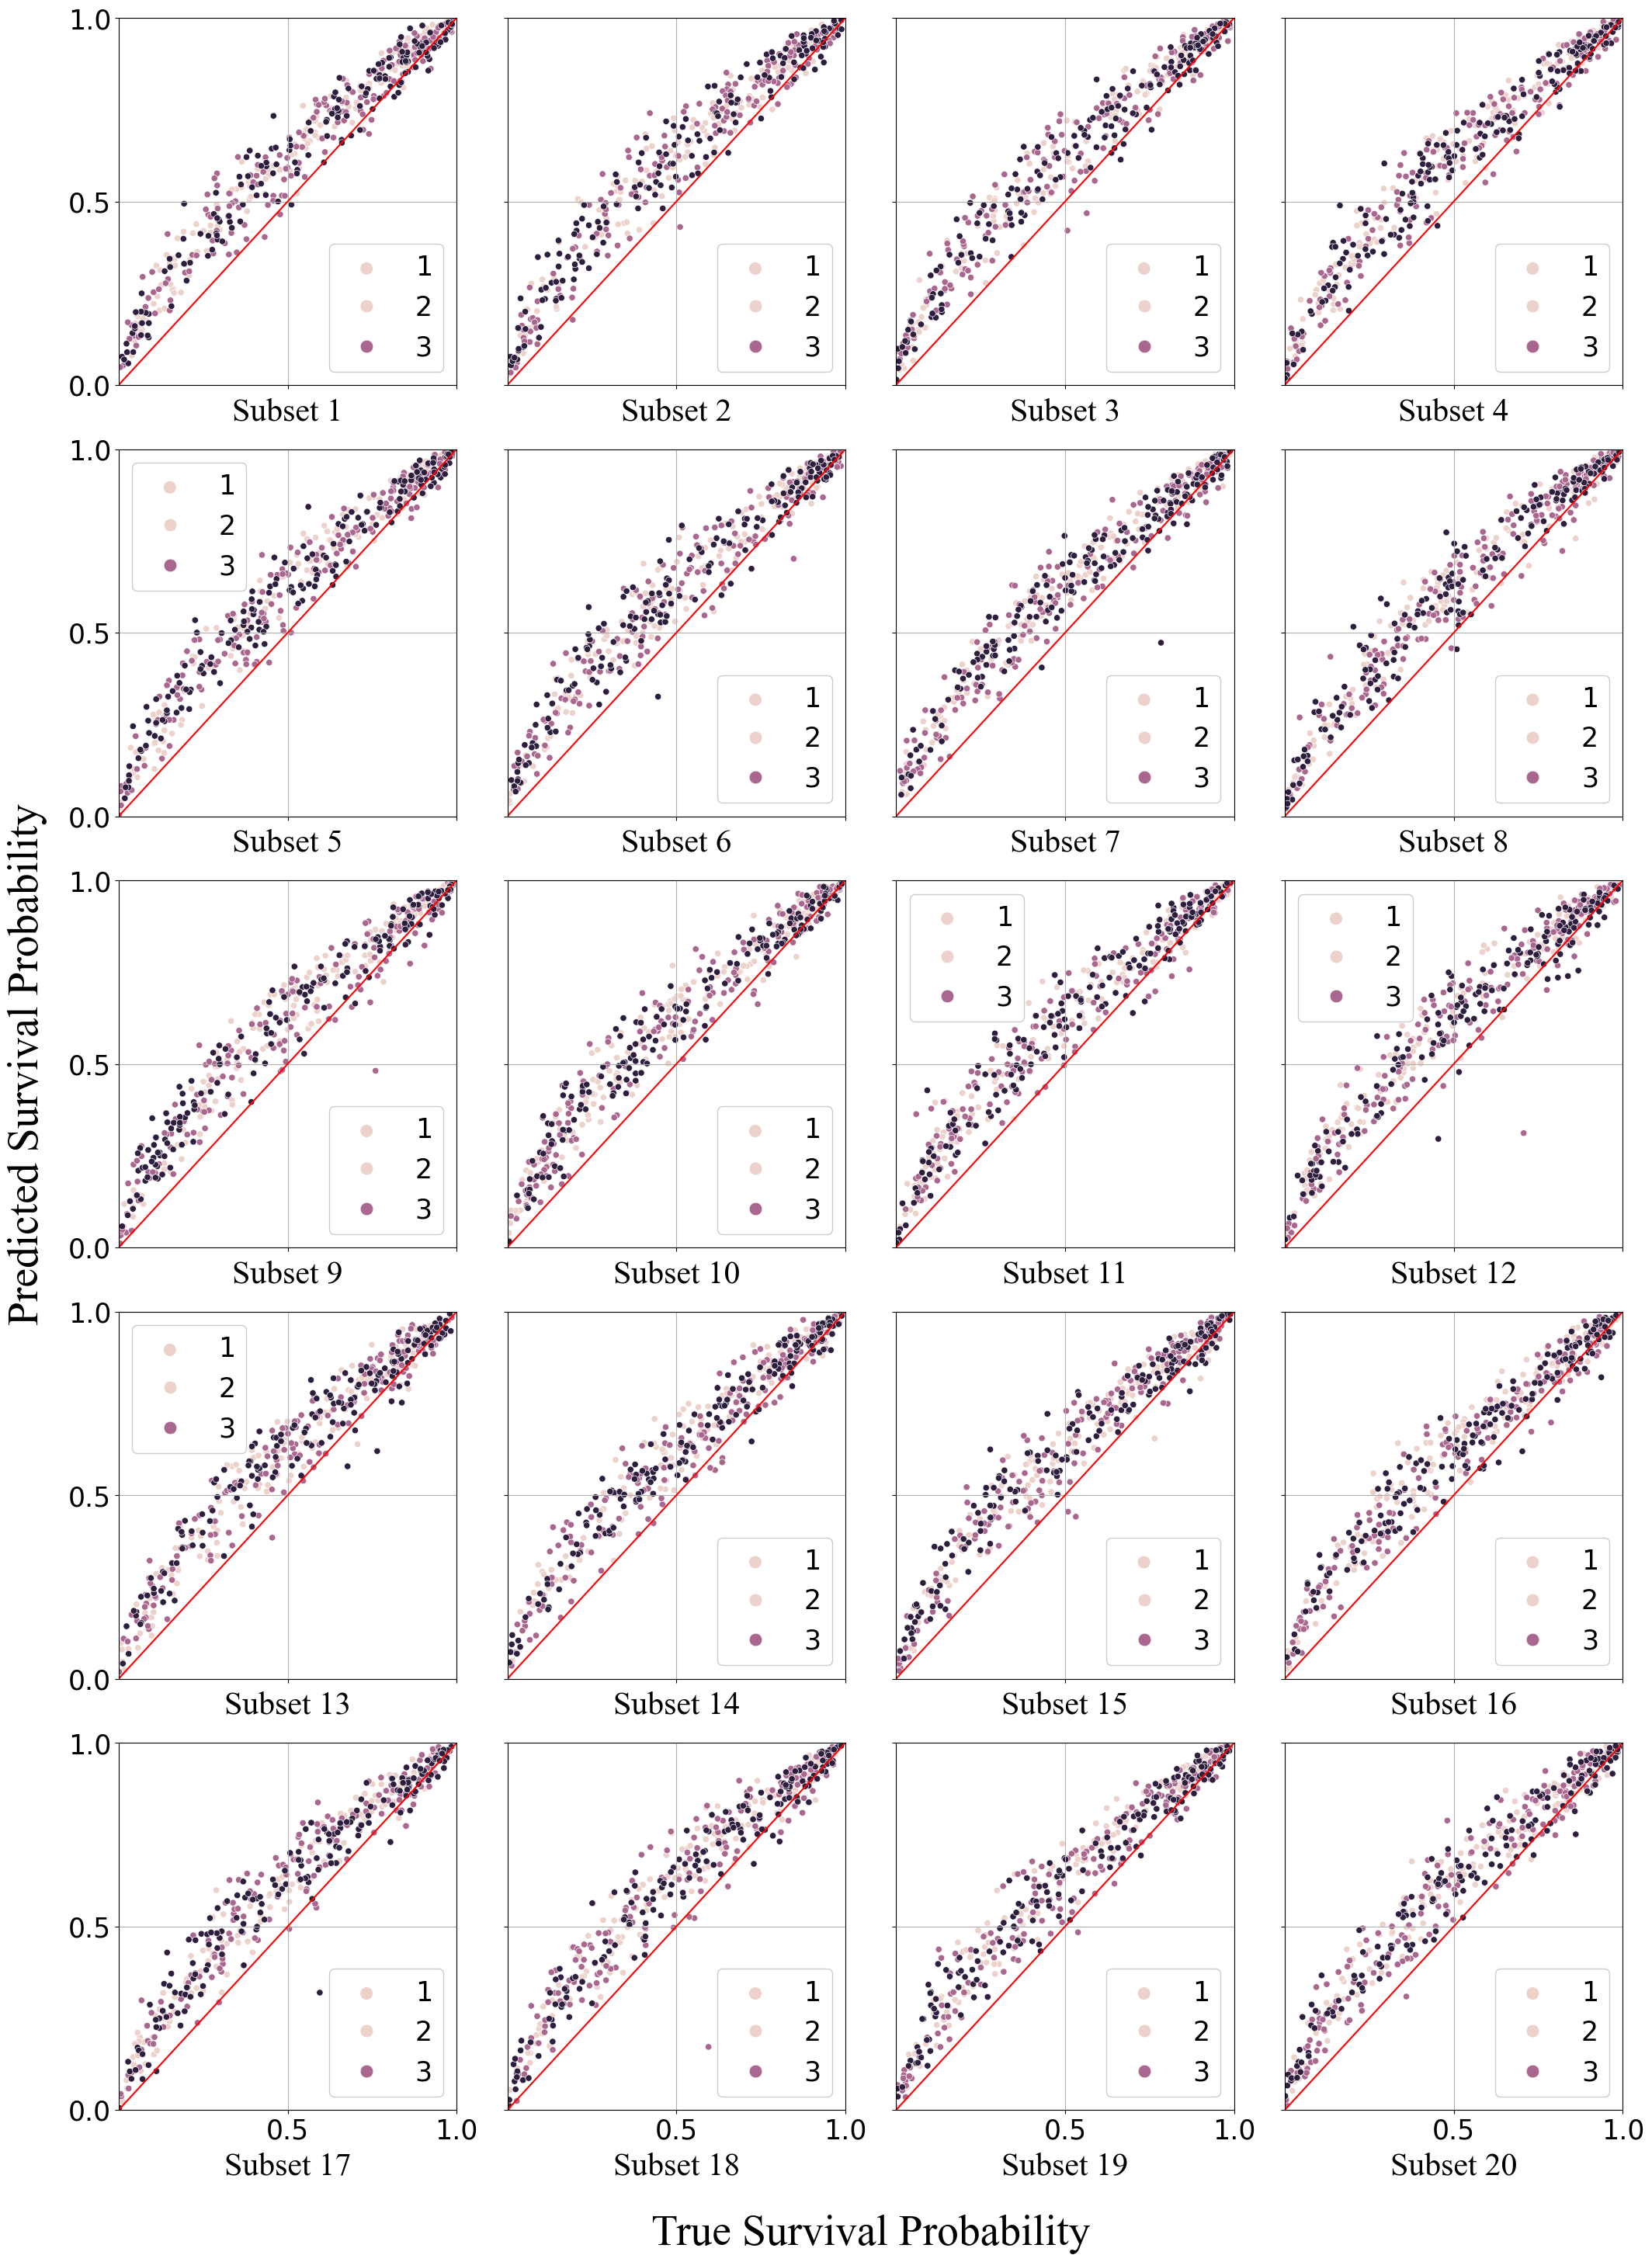

In [338]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

title_name = [f'Subset {i+1}' for i in range(20)]
fig, ax = plt.subplots(5,4, sharex=True, sharey=True, figsize=(25,35))
fig.subplots_adjust(wspace=0.15, hspace=0.175)


for i in range(5):
    for j in range(4):
        if i < 4:
            dddddd = EST_SF_TRAIN[4*i+j]
            sns.scatterplot(dddddd, x='true_sf', y='est_sf', hue='true_z', ax=ax[i,j])
            sns.lineplot(x=[0,1], y=[0,1], color='red', ax=ax[i,j])
            ax[i,j].set_xlabel('', fontsize=25)
            ax[i,j].set_xlim([0,1])
            ax[i,j].set_ylabel('', fontsize=25)
            ax[i,j].set_ylim([0,1])
            ax[i,j].tick_params(axis="x", labelsize=25)
            ax[i,j].tick_params(axis="y", labelsize=25)
            ax[i,j].set_title(title_name[4*i+j], y=0.04, pad=-25, verticalalignment="top", fontdict=font)
            ax[i,j].legend([1,2,3], fontsize=25, framealpha=1, markerscale=2)
            ax[i,j].set_xticks([0.5,1])
            ax[i,j].set_yticks([0,0.5,1])
            # ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
            ax[i,j].grid()
        else:
            dddddd = EST_SF_TEST[i-4+j]
            sns.scatterplot(dddddd, x='true_sf', y='est_sf', hue='true_z', ax=ax[i,j])
            sns.lineplot(x=[0,1], y=[0,1], color='red', ax=ax[i,j])
            ax[i,j].set_xlabel('', fontsize=25)
            ax[i,j].set_xlim([0,1])
            ax[i,j].set_ylabel('', fontsize=25)
            ax[i,j].set_ylim([0,1])
            ax[i,j].tick_params(axis="x", labelsize=25)
            ax[i,j].tick_params(axis="y", labelsize=25)
            ax[i,j].legend([1,2,3], fontsize=25, framealpha=1, markerscale=2)
            ax[i,j].set_title(title_name[4*i+j], y=-0.04, pad=-25, verticalalignment="top", fontdict=font)
            # ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
            ax[i,j].grid()

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("True Survival Probability", fontsize=40, y=-6, labelpad=80, verticalalignment="top", fontdict=font)
plt.ylabel("Predicted Survival Probability", fontsize=40, x=-5, labelpad=80, verticalalignment="top", fontdict=font)
plt.show()
fig.savefig('Performance across subsets.png')

In [45]:
aagg_z_y_test = pd.concat(Agg_z_y_test, ignore_index=True)
Pred_sf_train = pd.concat(EST_SF_TRAIN_16_SUBSETS,ignore_index=True)
Pred_sf_test = pd.concat(EST_SF_TEST_4_SUBSETS, ignore_index=True)
CItrain = []
CItest = []
for i in range(50):
    train_correct = []
    train_incorrect = []
    test_correct = []
    test_incorrect = []
    train_base = []
    test_base = []
    for j in range(3):
        time_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'y'].values
        time_test = Testing.loc[aagg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'y'].values
        event_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'C'].values
        event_test = Testing.loc[aagg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'C'].values
        pred_train = Training.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
        pred_test = Testing.loc[aagg_z_y_test[f'z_y_{i+1}_iteration'] == j, 'true_sf'].values
        c_train_true = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
        c_test_true = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
        pred_train = Pred_sf_train.loc[AGG_Z_Y[f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
        pred_test = Pred_sf_test.loc[aagg_z_y_test[f'z_y_{i+1}_iteration'] == j, f'{i+1}th_sf'].values
        c_train_pred = concordance_index_censored(event_train.astype(bool), time_train, pred_train)
        c_test_pred = concordance_index_censored(event_test.astype(bool), time_test, pred_test)
        ci_train_true = c_train_true[0]
        ci_test_true = c_test_true[0]
        correct_train_true = c_train_true[1]
        incorrect_train_true = c_train_true[2]
        correct_test_true = c_test_true[1]
        incorrect_test_true = c_test_true[2]
        ci_train_pred = c_train_pred[0]
        ci_test_pred = c_test_pred[0]
        correct_train_pred = c_train_pred[1]
        incorrect_train_pred = c_train_pred[2]
        correct_test_pred = c_test_pred[1]
        incorrect_test_pred = c_test_pred[2]
        train_base.append(incorrect_train_true)
        test_base.append(incorrect_test_true)
        train_correct.append(incorrect_train_pred)
        test_correct.append(incorrect_test_pred)
    citrain = sum(train_correct)/sum(train_base)
    citest = sum(test_correct)/sum(test_base)
    CItrain.append(1/citrain)
    CItest.append(1/citest)

pd.DataFrame({'C-index-train':[np.mean(CItrain), np.std(CItrain)], 'C-index-test':[np.mean(CItest), np.std(CItest)]}, index=['mean', 'std'])

,C-index-train,C-index-test
mean,0.982141,0.976429
std,0.005148,0.005695


In [56]:
pred_sf_unit = pd.concat([Pred_sf_train, Pred_sf_test], ignore_index=True)
pred_sf_unit = pred_sf_unit.mean(axis=1)
pred_sf_unit.to_csv('pred_sf_unit.csv')